#### Dependencies

In [145]:
import os
os.environ["USE_KEOPS"] = "0"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.api as sm

from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter
from sklearn.model_selection import KFold
from scipy.stats import gaussian_kde, norm
from sklearn.model_selection import train_test_split
from matplotlib.ticker import FuncFormatter
from lifelines.plotting import add_at_risk_counts
from lifelines.utils import concordance_index

from __future__ import annotations
from collections import Counter
from dataclasses import dataclass
import hashlib
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from lifelines.statistics import logrank_test
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import linear_sum_assignment

from synthcity.plugins import Plugins
from synthcity.plugins.core.dataloader import SurvivalAnalysisDataLoader
from synthcity.plugins.core.dataloader import GenericDataLoader

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

#### Datasets

In [147]:
lical0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/lical0_processed_data_for_fp_model_21-01-2026.csv')
miro0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/miro0_processed_data_for_fp_model_21-01-2026.csv')
# ril_3010 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/ril_3010_processed_data_for_fp_model_21-01-2026.csv')

proact0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/proact0_processed_data_for_fp_model_21-01-2026.csv')

MND_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/Sarah_MNDRegisterDataset_licals_02_amara.csv')
MND_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/All_MNDRegisterDataset_mirocals_random_index_date.csv')
# MND_rilu = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_riluzole.csv')

In [148]:
MND_miro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 65 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient_ID                       1838 non-null   float64
 1   Site_code                        1838 non-null   object 
 2   AgeOfOnset                       1838 non-null   float64
 3   SiteofOnset                      1798 non-null   object 
 4   Gender                           1820 non-null   object 
 5   AgeDeath                         1208 non-null   float64
 6   DiagnosticDelay_days             1434 non-null   float64
 7   YearFollowUp                     689 non-null    object 
 8   FVCLitres                        793 non-null    float64
 9   FVCPercentofPredicted            842 non-null    float64
 10  Diagnosis                        1838 non-null   object 
 11  Site_code_mndx                   1838 non-null   object 
 12  ConsentRegister     

In [149]:
miro0.head(3)

,subject_id,Event,Vital_capacity,El_Escorial,Onset_to_Rand,Age_Onset,Diagnostic_Delay,Study_Duration,Age_Diag,Enrollment_Delay,ALSFRS_RT,ALSFRS_Rasch,slope,Disease_DurationD,Onset_site_Limb,Sex_Male,Study_Arm_Placebo
0,1-62478,1,99.0,0,18.432,69.391,15.108,11.742444,70.650,3.324,39.0,28.4,-0.766450,15.066444,1,0,1
1,1-62479,1,81.0,1,19.644,63.754,15.600,5.500657,65.054,4.044,25.0,20.1,-4.181319,9.544657,0,0,0
2,1-62480,0,96.0,0,10.284,56.167,8.904,22.024967,56.909,1.380,42.0,31.1,-0.272418,23.404967,1,1,0


In [150]:
# miro0['Enrollment_Delay'] = miro0['Enrollment_Delay'] + 3

In [151]:
# miro0.head(3)

In [152]:
lical0.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Onset_to_Rand,Age_Onset,Diagnostic_Delay,Study_Duration,Age_Diag,Enrollment_Delay,ALSFRS_RT,ALSFRS_Rasch,slope,Disease_DurationD,Onset_site_Limb,Sex_Male,Study_Arm_Placebo
0,P01001,0,107.0,0,33.544148,51.967146,5.880420,19.000000,52.457221,27.660972,35.0,25.7,-0.684211,30.958607,1,1,1
1,P01002,1,99.0,0,18.562628,59.613963,9.526938,19.528252,60.407940,9.034166,43.0,32.2,-0.256039,27.562418,1,0,1


In [153]:
proact0.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Age_Diag,Diagnostic_Delay,Study_Duration_months,slope,ALSFRS_Rasch,ALSFRS_RT,Enrollment_Delay,Disease_DurationD,el_es,Onset_to_Rand,Onset_site_Limb,Sex_Male,Study_Arm_Placebo
0,121,1,63.037137,50.997947,51.584887,7.042707,17.557162,-1.196093,21.1,27.0,4.980946,22.538108,0,12.023653,1,0,0
1,226,1,56.228941,70.743326,71.594689,10.215506,13.910644,-1.581523,20.6,26.0,4.863338,18.773982,0,15.078844,0,1,0


In [154]:
# MND_miro.columns

In [155]:
MND_lica = MND_lica[['Patient_ID', 'New_event', 'FVCPercentofPredicted','AgeOfOnset', 'DiagnosticDelay_months',
                     'disease_duration_months', 'slope', 'ALSFRS_R', 'ElEscorial_Definite', 'Onset_Limb','Sex_Male']].copy()

MND_miro = MND_miro[['Patient_ID', 'Event', 'FVC_imputed','AgeOfOnset','DiagnosticDelay_months_imputed',
                     'disease_duration_months_imputed', 'Study_Duration_months', 'slope', 'ALSFRS_imputed', 'ElEscorial_Definite', 'Onset_Limb','Sex_Male']].copy()

In [156]:
# proact0 = proact0[proact0['Disease_Duration'] < 120]
lical0 = lical0.rename(columns={'Onset_site_Limb': 'Onset_Limb'})
miro0 = miro0.rename(columns={'Onset_site_Limb': 'Onset_Limb'})
proact0 = proact0.rename(columns={'Onset_site_Limb': 'Onset_Limb', 'el_es': 'El_Escorial', 'Study_Duration_months': 'Study_Duration'})

MND_lica = MND_lica.rename(columns={'Patient_ID': 'subject_id', 'New_event': 'Event', 'ElEscorial_Definite': 'El_Escorial', 'FVCPercentofPredicted': 'Vital_capacity',
                                    'AgeOfOnset': 'Age_Onset', 'ALSFRS_R': 'ALSFRS_RT', 'DiagnosticDelay_months': 'Diagnostic_Delay', 'disease_duration_months': 'Disease_DurationD'})

MND_miro = MND_miro.rename(columns={'Patient_ID': 'subject_id', 'ElEscorial_Definite': 'El_Escorial', 'FVC_imputed': 'Vital_capacity', 'Study_Duration_months': 'Study_Duration',
                                    'AgeOfOnset': 'Age_Onset', 'ALSFRS_imputed': 'ALSFRS_RT', 'DiagnosticDelay_months_imputed': 'Diagnostic_Delay', 'disease_duration_months_imputed': 'Disease_DurationD'})

In [157]:
lical0 = lical0.drop(['Age_Diag', 'Enrollment_Delay', 'ALSFRS_Rasch', 'Study_Duration'], axis=1)
lical0.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Onset_to_Rand,Age_Onset,Diagnostic_Delay,ALSFRS_RT,slope,Disease_DurationD,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,P01001,0,107.0,0,33.544148,51.967146,5.880420,35.0,-0.684211,30.958607,1,1,1
1,P01002,1,99.0,0,18.562628,59.613963,9.526938,43.0,-0.256039,27.562418,1,0,1


In [158]:
miro0 = miro0.drop(['Age_Diag', 'Enrollment_Delay', 'ALSFRS_Rasch', 'Onset_to_Rand'], axis=1)
miro0.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Age_Onset,Diagnostic_Delay,Study_Duration,ALSFRS_RT,slope,Disease_DurationD,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,1-62478,1,99.0,0,69.391,15.108,11.742444,39.0,-0.766450,15.066444,1,0,1
1,1-62479,1,81.0,1,63.754,15.600,5.500657,25.0,-4.181319,9.544657,0,0,0


In [159]:
proact0 = proact0.drop(['Age_Diag', 'Enrollment_Delay', 'ALSFRS_Rasch', 'Study_Duration'], axis=1)
proact0.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,slope,ALSFRS_RT,Disease_DurationD,El_Escorial,Onset_to_Rand,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,121,1,63.037137,50.997947,7.042707,-1.196093,27.0,22.538108,0,12.023653,1,0,0
1,226,1,56.228941,70.743326,10.215506,-1.581523,26.0,18.773982,0,15.078844,0,1,0


In [160]:
MND_miro.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Disease_DurationD,Study_Duration,slope,ALSFRS_RT,El_Escorial,Onset_Limb,Sex_Male
0,2.0,0,79.0,63.869999,3.613666,25.840042,21.0,-1.586685,7.0,0,1,1
1,3.0,0,127.0,69.480003,24.244415,289.000000,21.0,-0.114187,15.0,0,0,0


In [161]:
# MND_miro

In [162]:
MND_miro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1838 non-null   float64
 1   Event              1838 non-null   int64  
 2   Vital_capacity     1838 non-null   float64
 3   Age_Onset          1838 non-null   float64
 4   Diagnostic_Delay   1838 non-null   float64
 5   Disease_DurationD  1838 non-null   float64
 6   Study_Duration     1838 non-null   float64
 7   slope              1838 non-null   float64
 8   ALSFRS_RT          1838 non-null   float64
 9   El_Escorial        1838 non-null   int64  
 10  Onset_Limb         1838 non-null   int64  
 11  Sex_Male           1838 non-null   int64  
dtypes: float64(8), int64(4)
memory usage: 172.4 KB


##### Proact with eligibility criteria

In [163]:
# proact_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_miro_full.csv')
# proact_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_lica_full.csv')

# proact_miro['slope'] = (48 - proact_miro['ALSFRS_RT']) / proact_miro['Disease_Duration']
# proact_lica['slope'] = (48 - proact_lica['ALSFRS_RT']) / proact_lica['Disease_Duration']

# binss = [-np.inf, 0.31, 1.17, np.inf]
# labelss = ["Slow", "Intermediate", "Fast"]

# proact_miro["Progression_group"] = pd.cut(proact_miro["slope"], bins=binss, labels=labelss)
# proact_lica["Progression_group"] = pd.cut(proact_lica["slope"], bins=binss, labels=labelss)

#### **Select only the treatment arm**

In [164]:
lical0_trt = lical0[lical0['Study_Arm_Placebo'] == 0].copy()
miro0_trt = miro0[miro0['Study_Arm_Placebo'] == 0].copy()
# miroli0_trt = miroli0[miroli0['Study_Arm_Placebo'] == 0].copy()
# ril_3010_trt = ril_3010[ril_3010['Study_Arm_Placebo'] == 0].copy()
proact0_trt = proact0[proact0['Study_Arm_Placebo'] == 0].copy() 

#### **Select only the placebo arm**

In [165]:
lical0_pla = lical0[lical0['Study_Arm_Placebo'] == 1].copy()
miro0_pla = miro0[miro0['Study_Arm_Placebo'] == 1].copy()
# miroli0_pla = miroli0[miroli0['Study_Arm_Placebo'] == 1].copy()
# ril_3010_pla = ril_3010[ril_3010['Study_Arm_Placebo'] == 1].copy()
proact0_pla = proact0[proact0['Study_Arm_Placebo'] == 1].copy() 

#### **Choosing cohorts**

In [166]:
# MND_lica.columns

In [167]:
miro0_trt.columns

Index(['subject_id', 'Event', 'Vital_capacity', 'El_Escorial', 'Age_Onset',
       'Diagnostic_Delay', 'Study_Duration', 'ALSFRS_RT', 'slope',
       'Disease_DurationD', 'Onset_Limb', 'Sex_Male', 'Study_Arm_Placebo'],
      dtype='object')

In [168]:
MND_miro['Study_Arm_Placebo'] = 1
MND_lica['Study_Arm_Placebo'] = 1

# MND_miro = MND_miro.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})
# MND_lica = MND_lica.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})
MND_miro.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Disease_DurationD,Study_Duration,slope,ALSFRS_RT,El_Escorial,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,2.0,0,79.0,63.869999,3.613666,25.840042,21.0,-1.586685,7.0,0,1,1,1
1,3.0,0,127.0,69.480003,24.244415,289.000000,21.0,-0.114187,15.0,0,0,0,1


In [169]:
miro0_trt.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Age_Onset,Diagnostic_Delay,Study_Duration,ALSFRS_RT,slope,Disease_DurationD,Onset_Limb,Sex_Male,Study_Arm_Placebo
1,1-62479,1,81.0,1,63.754,15.600,5.500657,25.0,-4.181319,9.544657,0,0,0
2,1-62480,0,96.0,0,56.167,8.904,22.024967,42.0,-0.272418,23.404967,1,1,0


In [170]:
miro0_trt_for_mnd_data = miro0_trt #[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay', 'slope']]
lica0_trt_for_mnd_data = lical0_trt #[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay', 'slope']]

miro0_pla_for_mnd_data = miro0_pla #[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay', 'slope']]
lica0_pla_for_mnd_data = lical0_pla #[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Diag', 'Diagnostic_Delay', 'Sex_Male', 'Onset_Limb', 'Enrollment_Delay', 'slope']]


In [171]:
MND_miro.head(2)

,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Disease_DurationD,Study_Duration,slope,ALSFRS_RT,El_Escorial,Onset_Limb,Sex_Male,Study_Arm_Placebo
0,2.0,0,79.0,63.869999,3.613666,25.840042,21.0,-1.586685,7.0,0,1,1,1
1,3.0,0,127.0,69.480003,24.244415,289.000000,21.0,-0.114187,15.0,0,0,0,1


#### **Propensity score matching**

In [172]:
# ============================================================
# PROPENSITY SCORE + OVERLAP
# ============================================================
def fit_ps_trim_weight(
    df: pd.DataFrame,
    covariates: List[str],
    penalty: str = "l2",
    C: float = 1.0,
    trim: bool = True,
    weight_method: str = "overlap",
    ps_col: str = "ps",
    group_col: str = "Group",
    verbose: bool = True
) -> Tuple[pd.DataFrame, Pipeline]:
    """
    Fit a logistic-regression propensity score model, optionally trim to common
    support, and add balancing weights.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing covariates and treatment/group indicator.
    covariates : List[str]
        Covariates used in the propensity score model.
    penalty : str, default="l2"
        LogisticRegression penalty.
    C : float, default=1.0
        Inverse regularization strength for LogisticRegression.
    trim : bool, default=True
        If True, trim observations outside the common support region.
    weight_method : str, default="overlap"
        Weighting scheme. Supported:
        - "overlap"
        - "iptw"
        - "unstabilized"
    ps_col : str, default="ps"
        Name of the propensity score column to create/use.
    group_col : str, default="Group"
        Name of binary treatment/group column (0 = control, 1 = treated).
    verbose : bool, default=True
        If True, print AUC and trimming summary.

    Returns
    -------
    Tuple[pd.DataFrame, Pipeline]
        Processed dataframe and fitted sklearn pipeline.
    """
    # -----------------------------
    # Validate inputs
    # -----------------------------
    required_cols = set(covariates + [group_col])
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    x = df[covariates].copy()
    y = df[group_col].astype(int).values

    if not set(np.unique(y)).issubset({0, 1}):
        raise ValueError(f"{group_col} must be binary with values 0/1.")

    # -----------------------------
    # Build and fit PS model
    # -----------------------------
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, covariates)
        ],
        remainder="drop"
    )

    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver="lbfgs",
        max_iter=5000
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x, y)
    ps = pipe.predict_proba(x)[:, 1]
    ps_clipped = np.clip(ps, 1e-6, 1 - 1e-6)

    out = df.copy()
    out[ps_col] = ps
    out["ps_logit"] = np.log(ps_clipped / (1 - ps_clipped))

    auc = roc_auc_score(y, ps)
    if verbose:
        print(f"Propensity model AUC: {auc:.3f}")

    # -----------------------------
    # Optional trimming
    # -----------------------------
    if trim:
        ps_t = out.loc[out[group_col] == 1, ps_col]
        ps_c = out.loc[out[group_col] == 0, ps_col]

        lower_common = max(ps_t.min(), ps_c.min())
        upper_common = min(ps_t.max(), ps_c.max())

        before_n = len(out)
        out = out[(out[ps_col] >= lower_common) & (out[ps_col] <= upper_common)].copy()
        out = out.reset_index(drop=True)

        if verbose:
            print(f"Before trimming: {before_n}")
            print(f"After trimming:  {len(out)}")
            print(f"Removed:         {before_n - len(out)}")

    # -----------------------------
    # Add weights
    # -----------------------------
    ps_final = np.clip(out[ps_col].values, 1e-6, 1 - 1e-6)
    g = out[group_col].astype(int).values

    if weight_method == "overlap":
        w = np.where(g == 1, 1 - ps_final, ps_final)
    elif weight_method in ("iptw", "unstabilized"):
        w = np.where(g == 1, 1 / ps_final, 1 / (1 - ps_final))
    else:
        raise ValueError("weight_method must be 'overlap' or 'iptw'")

    out["weight"] = w

    return out, pipe




# ============================================================
# BALANCE DIAGNOSTICS
# ============================================================
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)


def smd_continuous(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        mt = np.nanmean(x_t)
        vt = np.nanvar(x_t, ddof=0)
    else:
        mt = weighted_mean(x_t, w_t)
        vt = weighted_var(x_t, w_t)

    if w_c is None:
        mc = np.nanmean(x_c)
        vc = np.nanvar(x_c, ddof=0)
    else:
        mc = weighted_mean(x_c, w_c)
        vc = weighted_var(x_c, w_c)

    pooled_sd = np.sqrt((vt + vc) / 2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan
    return (mt - mc) / pooled_sd


def smd_binary(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        pt = np.nanmean(x_t)
    else:
        pt = weighted_mean(x_t, w_t)

    if w_c is None:
        pc = np.nanmean(x_c)
    else:
        pc = weighted_mean(x_c, w_c)

    p = (pt + pc) / 2
    denom = np.sqrt(p * (1 - p))
    if denom == 0 or np.isnan(denom):
        return np.nan
    return (pt - pc) / denom


def balance_table(df: pd.DataFrame, covariates: List[str], weight_col: Optional[str] = None) -> pd.DataFrame:
    rows = []

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    for col in covariates:
        xt = treated[col].astype(float)
        xc = control[col].astype(float)

        mask_t = xt.notna()
        mask_c = xc.notna()
        xt = xt[mask_t]
        xc = xc[mask_c]

        wt = treated.loc[mask_t, weight_col].values if weight_col is not None else None
        wc = control.loc[mask_c, weight_col].values if weight_col is not None else None

        uniq = pd.concat([xt, xc]).dropna().unique()
        is_binary = set(np.unique(uniq)).issubset({0.0, 1.0})

        if is_binary:
            smd = smd_binary(xt, xc, wt, wc)
        else:
            smd = smd_continuous(xt, xc, wt, wc)

        if weight_col is None:
            mt = np.nanmean(xt)
            mc = np.nanmean(xc)
        else:
            mt = weighted_mean(xt.values, wt)
            mc = weighted_mean(xc.values, wc)

        rows.append({
            "Variable": col,
            "Treated_mean": mt,
            "Control_mean": mc,
            "SMD": smd,
            "Abs_SMD": np.abs(smd)
        })

    out = pd.DataFrame(rows).sort_values("Abs_SMD", ascending=False).reset_index(drop=True)
    return out


# ============================================================
# SURVIVAL ANALYSIS
# ============================================================
def weighted_km_plot(
    df: pd.DataFrame,
    time_col: str = "Time",
    event_col: str = "Event",
    weight_col: Optional[str] = "weight",
    title: str = "Weighted Kaplan-Meier",
    x_max: Optional[float] = None
):
    plt.figure(figsize=(5, 4))

    km_t = KaplanMeierFitter()
    km_c = KaplanMeierFitter()

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    km_t.fit(
        durations=treated[time_col],
        event_observed=treated[event_col],
        weights=treated[weight_col] if weight_col else None,
        label="Treated"
    )
    km_c.fit(
        durations=control[time_col],
        event_observed=control[event_col],
        weights=control[weight_col] if weight_col else None,
        label="External control"
    )

    ax = km_t.plot_survival_function(ci_show=True)
    km_c.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlabel("Disease Duration")
    ax.set_ylabel("Survival probability")
    ax.set_title(title)
    ax.set_ylim(0,1.02)
    ax.grid(True, alpha=0.3)
    if x_max is not None:
        ax.set_xlim(0, x_max)
    plt.tight_layout()
    plt.show()
    


#### **Prepare data**

In [173]:
# combine treated and  placebo patients
# lical and MND_lical
lica0_trt_for_mnd_data['data'] = "lical0_trt"
MND_lica['data'] = "MND_lica"
comb_mnd_lica_trt = pd.concat([lica0_trt_for_mnd_data, MND_lica], axis=0, ignore_index=True)
comb_mnd_lica_trt['Group'] = (comb_mnd_lica_trt['data'] == "lical0_trt").astype(int)

lica0_pla_for_mnd_data['data'] = "lical0_pla"
MND_lica['data'] = "MND_lica"
comb_mnd_lica_pla = pd.concat([lica0_pla_for_mnd_data, MND_lica], axis=0, ignore_index=True)
comb_mnd_lica_pla['Group'] = (comb_mnd_lica_pla['data'] == "lical0_pla").astype(int)

# mirocal and MND_mirocal
miro0_trt_for_mnd_data['data'] = "miro0_trt"
MND_miro['data'] = "MND_miro"
comb_mnd_miro_trt = pd.concat([miro0_trt_for_mnd_data, MND_miro], axis=0, ignore_index=True)
comb_mnd_miro_trt['Group'] = (comb_mnd_miro_trt['data'] == "miro0_trt").astype(int)

miro0_pla_for_mnd_data['data'] = "miro0_pla"
MND_miro['data'] = "MND_miro"
comb_mnd_miro_pla = pd.concat([miro0_pla_for_mnd_data, MND_miro], axis=0, ignore_index=True)
comb_mnd_miro_pla['Group'] = (comb_mnd_miro_pla['data'] == "miro0_pla").astype(int)


In [174]:
comb_mnd_miro_pla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1948 non-null   object 
 1   Event              1948 non-null   int64  
 2   Vital_capacity     1948 non-null   float64
 3   El_Escorial        1948 non-null   int64  
 4   Age_Onset          1948 non-null   float64
 5   Diagnostic_Delay   1948 non-null   float64
 6   Study_Duration     1948 non-null   float64
 7   ALSFRS_RT          1948 non-null   float64
 8   slope              1948 non-null   float64
 9   Disease_DurationD  1948 non-null   float64
 10  Onset_Limb         1948 non-null   int64  
 11  Sex_Male           1948 non-null   int64  
 12  Study_Arm_Placebo  1948 non-null   int64  
 13  data               1948 non-null   object 
 14  Group              1948 non-null   int64  
dtypes: float64(7), int64(6), object(2)
memory usage: 228.4+ KB


In [175]:
def log_transform_and_standardize_columns(df, cols):
    for col in cols:
        df[col + "_l"] = np.log1p(df[col])  # ln(1 + x)
    
    for col in df.select_dtypes(include=['float']).columns:
        df[col + '_std'] = (df[col] - df[col].mean()) / df[col].std()
    return df

cols_to_transform = ['Diagnostic_Delay']

comb_mnd_lica_trt = log_transform_and_standardize_columns(comb_mnd_lica_trt, cols_to_transform)
comb_mnd_miro_trt = log_transform_and_standardize_columns(comb_mnd_miro_trt, cols_to_transform)
comb_mnd_lica_pla = log_transform_and_standardize_columns(comb_mnd_lica_pla, cols_to_transform)
comb_mnd_miro_pla = log_transform_and_standardize_columns(comb_mnd_miro_pla, cols_to_transform)

comb_mnd_miro_trt.head(2)

,subject_id,Event,Vital_capacity,El_Escorial,Age_Onset,Diagnostic_Delay,Study_Duration,ALSFRS_RT,slope,Disease_DurationD,Onset_Limb,Sex_Male,Study_Arm_Placebo,data,Group,Diagnostic_Delay_l,Vital_capacity_std,Age_Onset_std,Diagnostic_Delay_std,Study_Duration_std,ALSFRS_RT_std,slope_std,Disease_DurationD_std,Diagnostic_Delay_l_std
0,1-62479,1,81.0,1,63.754,15.600,5.500657,25.0,-4.181319,9.544657,0,0,0,miro0_trt,1,2.809403,-1.261706,0.568878,-0.106247,-2.546482,-1.125445,-1.800390,-0.807437,0.241402
1,1-62480,0,96.0,0,56.167,8.904,22.024967,42.0,-0.272418,23.404967,1,1,0,miro0_trt,1,2.292939,-0.127689,-0.093332,-0.421298,0.684641,0.951908,0.233411,-0.531908,-0.476898


In [176]:
# comb_mnd_miro_trt.describe()

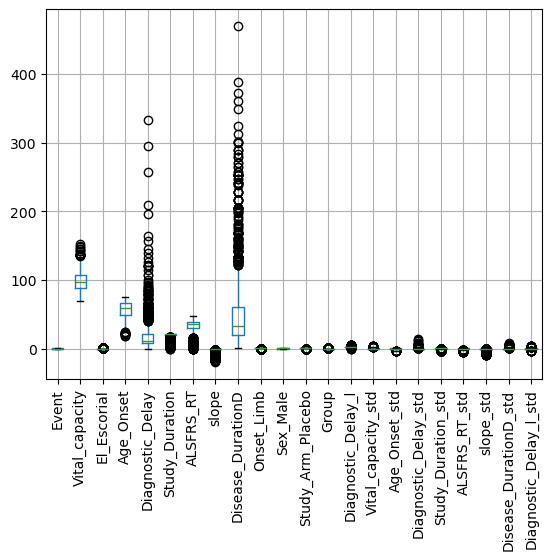

In [177]:
comb_mnd_miro_trt.boxplot(rot=90)
plt.show()

In [178]:
# comb_mnd_lica_trt["ALSFRS_RT_std"].hist()

In [179]:
comb_mnd_miro_trt.columns

Index(['subject_id', 'Event', 'Vital_capacity', 'El_Escorial', 'Age_Onset',
       'Diagnostic_Delay', 'Study_Duration', 'ALSFRS_RT', 'slope',
       'Disease_DurationD', 'Onset_Limb', 'Sex_Male', 'Study_Arm_Placebo',
       'data', 'Group', 'Diagnostic_Delay_l', 'Vital_capacity_std',
       'Age_Onset_std', 'Diagnostic_Delay_std', 'Study_Duration_std',
       'ALSFRS_RT_std', 'slope_std', 'Disease_DurationD_std',
       'Diagnostic_Delay_l_std'],
      dtype='object')

In [180]:
comb_mnd_lica_trt = comb_mnd_lica_trt[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Onset_std', 'Diagnostic_Delay_l_std','El_Escorial', 'Sex_Male', 'Onset_Limb', 'ALSFRS_RT_std', 'Vital_capacity_std','data', 'Group', 'slope_std']]
comb_mnd_miro_trt = comb_mnd_miro_trt[['subject_id', 'Event', 'Study_Duration','Study_Arm_Placebo', 'Age_Onset_std', 'Diagnostic_Delay_l_std','El_Escorial', 'Sex_Male', 'Onset_Limb', 'ALSFRS_RT_std', 'Vital_capacity_std','data', 'Group', 'slope_std']]
comb_mnd_lica_pla = comb_mnd_lica_pla[['subject_id', 'Event', 'Disease_DurationD','Study_Arm_Placebo', 'Age_Onset_std', 'Diagnostic_Delay_l_std','El_Escorial', 'Sex_Male', 'Onset_Limb', 'ALSFRS_RT_std', 'Vital_capacity_std','data', 'Group', 'slope_std']]
comb_mnd_miro_pla = comb_mnd_miro_pla[['subject_id', 'Event', 'Study_Duration','Study_Arm_Placebo', 'Age_Onset_std', 'Diagnostic_Delay_l_std', 'El_Escorial','Sex_Male', 'Onset_Limb', 'ALSFRS_RT_std', 'Vital_capacity_std','data', 'Group', 'slope_std']]

comb_mnd_lica_trt = comb_mnd_lica_trt.rename(columns={'Disease_DurationD': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'ALSFRS_RT_std':'ALSFRS', 'Age_Onset_std': 'Age', 'slope_std': 'slope', 'Vital_capacity_std': 'Vital_capacity'})
comb_mnd_miro_trt = comb_mnd_miro_trt.rename(columns={'Study_Duration': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'ALSFRS_RT_std':'ALSFRS', 'Age_Onset_std': 'Age', 'slope_std': 'slope', 'Vital_capacity_std': 'Vital_capacity'})
comb_mnd_lica_pla = comb_mnd_lica_pla.rename(columns={'Disease_DurationD': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'ALSFRS_RT_std':'ALSFRS', 'Age_Onset_std': 'Age', 'slope_std': 'slope', 'Vital_capacity_std': 'Vital_capacity'})
comb_mnd_miro_pla = comb_mnd_miro_pla.rename(columns={'Study_Duration': 'Disease_Duration', 'Diagnostic_Delay_l_std': 'Diagnostic_Delay', 'ALSFRS_RT_std':'ALSFRS', 'Age_Onset_std': 'Age', 'slope_std': 'slope', 'Vital_capacity_std': 'Vital_capacity'})

comb_mnd_lica_trt.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope
0,P01003,0,27.949409,0,-1.162149,-1.215391,0,1,1,1.013816,0.694002,lical0_trt,1,0.358018
1,P01004,0,26.402431,0,-1.063887,-1.965942,0,1,1,1.152002,0.502150,lical0_trt,1,0.378553


In [181]:
comb_mnd_miro_trt.head(3)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope
0,1-62479,1,5.500657,0,0.568878,0.241402,1,0,0,-1.125445,-1.261706,miro0_trt,1,-1.800390
1,1-62480,0,22.024967,0,-0.093332,-0.476898,0,1,1,0.951908,-0.127689,miro0_trt,1,0.233411
2,1-62482,1,9.541393,0,1.020738,-0.404661,1,0,0,0.707514,1.006328,miro0_trt,1,-0.061097


In [182]:
comb_mnd_miro_trt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1948 non-null   object 
 1   Event              1948 non-null   int64  
 2   Disease_Duration   1948 non-null   float64
 3   Study_Arm_Placebo  1948 non-null   int64  
 4   Age                1948 non-null   float64
 5   Diagnostic_Delay   1948 non-null   float64
 6   El_Escorial        1948 non-null   int64  
 7   Sex_Male           1948 non-null   int64  
 8   Onset_Limb         1948 non-null   int64  
 9   ALSFRS             1948 non-null   float64
 10  Vital_capacity     1948 non-null   float64
 11  data               1948 non-null   object 
 12  Group              1948 non-null   int64  
 13  slope              1948 non-null   float64
dtypes: float64(6), int64(6), object(2)
memory usage: 213.2+ KB


In [183]:
# comb_mnd_lica_trt['Diagnostic_Delay'].corr(comb_mnd_lica_trt['Disease_Duration'])

#### **Implement propensity score**

 **comb_mnd_lica_trt, comb_mnd_lica_pla, comb_mnd_miro_trt, comb_mnd_miro_pla**

 **comb_proact_lica_trt,  comb_proact_lica_pla, comb_proact_miro_trt, comb_proact_miro_pla**
 
 **comb_mnd_proact_miro_trt, comb_mnd_proact_miro_pla,  comb_mnd_proact_lica_trt, comb_mnd_proact_lica_pla**

In [184]:
comb_mnd_miro_trt.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope
0,1-62479,1,5.500657,0,0.568878,0.241402,1,0,0,-1.125445,-1.261706,miro0_trt,1,-1.800390
1,1-62480,0,22.024967,0,-0.093332,-0.476898,0,1,1,0.951908,-0.127689,miro0_trt,1,0.233411


In [185]:
comb_mnd_miro_trt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1948 non-null   object 
 1   Event              1948 non-null   int64  
 2   Disease_Duration   1948 non-null   float64
 3   Study_Arm_Placebo  1948 non-null   int64  
 4   Age                1948 non-null   float64
 5   Diagnostic_Delay   1948 non-null   float64
 6   El_Escorial        1948 non-null   int64  
 7   Sex_Male           1948 non-null   int64  
 8   Onset_Limb         1948 non-null   int64  
 9   ALSFRS             1948 non-null   float64
 10  Vital_capacity     1948 non-null   float64
 11  data               1948 non-null   object 
 12  Group              1948 non-null   int64  
 13  slope              1948 non-null   float64
dtypes: float64(6), int64(6), object(2)
memory usage: 213.2+ KB


In [186]:
covariates = ['Age', 'Disease_Duration', 'Onset_Limb', 'Sex_Male', 'El_Escorial', 'Vital_capacity', 'Diagnostic_Delay', 'ALSFRS'] #, 'Enrollment_Delay'

df_mnd_lica_trt, ps_mnd_lica_trt = fit_ps_trim_weight(df=comb_mnd_lica_trt, covariates=covariates, trim=False, weight_method="iptw") # iptw overlap
df_mnd_lica_pla, ps_mnd_lica_pla = fit_ps_trim_weight(df=comb_mnd_lica_pla, covariates=covariates, trim=False, weight_method="iptw")
df_mnd_miro_trt, ps_mnd_miro_trt = fit_ps_trim_weight(df=comb_mnd_miro_trt, covariates=covariates, trim=False, weight_method="iptw")
df_mnd_miro_pla, ps_mnd_miro_pla = fit_ps_trim_weight(df=comb_mnd_miro_pla, covariates=covariates, trim=False, weight_method="iptw")

Propensity model AUC: 0.874
Propensity model AUC: 0.885
Propensity model AUC: 0.839
Propensity model AUC: 0.820


In [187]:
comb_mnd_miro_trt.shape, df_mnd_miro_trt.shape

((1948, 14), (1948, 17))

In [188]:
df_mnd_miro_pla.head(3)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight
0,1-62478,1,11.742444,1,1.055609,0.194992,0,0,1,0.589500,0.100475,miro0_pla,1,-0.022171,0.028464,-3.530244,35.132294
1,1-62481,0,22.024967,1,1.151950,-0.791189,0,1,0,0.589500,-0.573955,miro0_pla,1,0.163602,0.034901,-3.319704,28.652152
2,1-62485,0,22.024967,1,-0.136804,-1.146821,0,1,1,1.442041,-0.648892,miro0_pla,1,0.328607,0.137246,-1.838359,7.286213


#### **Perform trial and register matching**

In [189]:
# df_mnd_lica_trt, df_mnd_lica_pla, df_mnd_miro_trt, df_mnd_miro_pla,

def trail_register_matched_with_replacement(df):
    # Split trial and register patients
    trial = df[df['Group'] == 1].copy()
    register = df[df['Group'] == 0].copy()

    trial = trial.reset_index(drop=True)
    register = register.reset_index(drop=True)

    # Nearest-neighbour matching
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(register[['ps']])
    distances, indices = nn.kneighbors(trial[['ps']])

    # Extract matched register controls
    matched_register = register.iloc[indices.flatten()].copy()
    matched_register['matched_trial_id'] = trial.index.values
    matched_register['ps_distance'] = distances.flatten()

    # combine matched trial and matched controls
    matched_trial = trial.copy()
    matched_trial['matched_trial_id'] = trial.index.values
    matched_trial['ps_distance'] = 0

    matched_data = pd.concat([matched_trial, matched_register], axis=0)
    return matched_data
# matched_data.shape


def trail_register_matched_without_replacement(df, caliper=0.05):
    trial = df[df["Group"] == 1].copy().reset_index(drop=True)
    register = df[df["Group"] == 0].copy().reset_index(drop=True)

    cost_matrix = np.abs(
        trial["ps"].values[:, None] - register["ps"].values[None, :]
    )

    penalty = 1e6
    cost_matrix_penalised = cost_matrix.copy()
    cost_matrix_penalised[cost_matrix_penalised > caliper] = penalty

    trial_indices, register_indices = linear_sum_assignment(cost_matrix_penalised)

    valid = cost_matrix_penalised[trial_indices, register_indices] < penalty

    trial_indices = trial_indices[valid]
    register_indices = register_indices[valid]

    matched_trial = trial.iloc[trial_indices].copy()
    matched_register = register.iloc[register_indices].copy()

    matched_trial["matched_trial_id"] = trial_indices
    matched_trial["ps_distance"] = 0

    matched_register["matched_trial_id"] = trial_indices
    matched_register["ps_distance"] = cost_matrix[trial_indices, register_indices]

    matched_data = pd.concat([matched_trial, matched_register], axis=0)

    return matched_data.reset_index(drop=True)


def trail_register_matched_without_replacement_keep_all_trial(df, caliper=0.05):
    trial = df[df["Group"] == 1].copy().reset_index(drop=True)
    register = df[df["Group"] == 0].copy().reset_index(drop=True)

    cost_matrix = np.abs(
        trial["ps"].values[:, None] - register["ps"].values[None, :]
    )

    penalty = 1e6
    cost_matrix_penalised = cost_matrix.copy()
    cost_matrix_penalised[cost_matrix_penalised > caliper] = penalty

    trial_indices, register_indices = linear_sum_assignment(cost_matrix_penalised)

    valid = cost_matrix_penalised[trial_indices, register_indices] < penalty

    valid_trial_indices = trial_indices[valid]
    valid_register_indices = register_indices[valid]

    # Keep ALL trial patients
    matched_trial = trial.copy()
    matched_trial["matched_trial_id"] = matched_trial.index
    matched_trial["ps_distance"] = 0
    matched_trial["matched_status"] = "trial_retained"

    # Keep only successfully matched register controls
    matched_register = register.iloc[valid_register_indices].copy()
    matched_register["matched_trial_id"] = valid_trial_indices
    matched_register["ps_distance"] = cost_matrix[
        valid_trial_indices,
        valid_register_indices
    ]
    matched_register["matched_status"] = "register_matched"

    matched_data = pd.concat(
        [matched_trial, matched_register],
        axis=0
    )

    return matched_data.reset_index(drop=True)


def trial_register_matched_one_to_many_keep_all_trial(df, n_matches=3, caliper=0.05):
    trial = df[df["Group"] == 1].copy().reset_index(drop=True)
    register = df[df["Group"] == 0].copy().reset_index(drop=True)

    used_register = set()
    matched_register_list = []

    # keep all trial patients
    matched_trial = trial.copy()
    matched_trial["matched_trial_id"] = matched_trial.index
    matched_trial["ps_distance"] = 0
    matched_trial["matched_status"] = "trial_retained"

    for i, trial_row in trial.iterrows():

        # available register patients only
        available_register = register.loc[
            ~register.index.isin(used_register)
        ].copy()

        if available_register.empty:
            continue

        # calculate distance in propensity score
        available_register["ps_distance"] = abs(
            available_register["ps"] - trial_row["ps"]
        )

        # keep only within caliper
        available_register = available_register[
            available_register["ps_distance"] <= caliper
        ]

        if available_register.empty:
            continue

        # choose nearest n_matches register patients
        selected = available_register.sort_values("ps_distance").head(n_matches).copy()

        selected["matched_trial_id"] = i
        selected["matched_status"] = "register_matched"

        matched_register_list.append(selected)

        # mark these register patients as already used
        used_register.update(selected.index.tolist())

    if matched_register_list:
        matched_register = pd.concat(matched_register_list, axis=0)
        matched_data = pd.concat([matched_trial, matched_register], axis=0)
    else:
        matched_data = matched_trial.copy()

    return matched_data.reset_index(drop=True)



In [190]:
# df_mnd_lica_trt, df_mnd_lica_pla, df_mnd_miro_trt, df_mnd_miro_pla,
# matched_data_wr = trail_register_matched_with_replacement(df_mnd_lica_trt)
matched_data_wor_mnd_lica_trt = trail_register_matched_without_replacement_keep_all_trial(df_mnd_lica_trt, caliper=0.05)
matched_data_wor_mnd_lica_pla = trail_register_matched_without_replacement_keep_all_trial(df_mnd_lica_pla, caliper=0.05)
matched_data_wor_mnd_miro_trt = trail_register_matched_without_replacement_keep_all_trial(df_mnd_miro_trt, caliper=0.05)
matched_data_wor_mnd_miro_pla = trail_register_matched_without_replacement_keep_all_trial(df_mnd_miro_pla, caliper=0.05)

# matched_data_wor_mnd_lica_trt_many = trial_register_matched_one_to_many_keep_all_trial(df_mnd_lica_trt, n_matches=3, caliper=0.1)
# matched_data_wor_mnd_lica_pla_many = trial_register_matched_one_to_many_keep_all_trial(df_mnd_lica_pla, n_matches=3, caliper=0.1)
matched_data_wor_mnd_miro_trt_many = trial_register_matched_one_to_many_keep_all_trial(df_mnd_miro_trt, n_matches=5, caliper=0.05)
matched_data_wor_mnd_miro_pla_many = trial_register_matched_one_to_many_keep_all_trial(df_mnd_miro_pla, n_matches=5, caliper=0.05)

# matched_data.groupby('Group')['ps'].describe()
# matched_data.groupby('Group')[covariates + ['ps']].mean()
matched_data_wor_mnd_miro_trt_many.shape# , matched_data_wr.shape

(574, 20)

In [191]:
print(matched_data_wor_mnd_miro_trt_many["Group"].value_counts())
matched_data_wor_mnd_miro_trt_many["matched_status"].value_counts()
# matched_data_wor_mnd_lica_trt_many.groupby(["matched_trial_id", "Group"]).size()

Group
0    464
1    110
Name: count, dtype: int64


matched_status
register_matched    464
trial_retained      110
Name: count, dtype: int64

#### **Implementation**

In [192]:
print(matched_data_wor_mnd_miro_trt_many.data.value_counts())
print()
print(matched_data_wor_mnd_miro_pla_many.data.value_counts())

data
MND_miro     464
miro0_trt    110
Name: count, dtype: int64

data
MND_miro     465
miro0_pla    110
Name: count, dtype: int64


In [193]:
mnd_pla_for_trial_trt = matched_data_wor_mnd_miro_trt_many[matched_data_wor_mnd_miro_trt_many['data'] == 'MND_miro'].copy()
mnd_pla_for_trial_pla = matched_data_wor_mnd_miro_pla_many[matched_data_wor_mnd_miro_pla_many['data'] == 'MND_miro'].copy()

# mnd_pla_for_trial_pla['weight'] = 1
mnd_pla_for_trial_trt.head(3)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status
110,1760.0,1,11.124000,1,1.483246,-0.024269,0,1,0,0.526662,-0.052088,MND_miro,0,0.177852,0.013310,-4.305874,1.013489,0,0.000006,register_matched
111,299.0,1,13.932013,1,0.345960,-0.768586,0,0,0,0.303041,1.611137,MND_miro,0,0.153591,0.013307,-4.306096,1.013486,0,0.000008,register_matched
112,732.0,1,12.791989,1,-1.292326,-0.976886,0,0,1,-1.083898,-1.110503,MND_miro,0,-0.261460,0.013350,-4.302763,1.013531,0,0.000035,register_matched


In [194]:
trial_trt = matched_data_wor_mnd_miro_trt_many[matched_data_wor_mnd_miro_trt_many["data"] == 'miro0_trt'].copy()
trial_pla = matched_data_wor_mnd_miro_pla_many[matched_data_wor_mnd_miro_pla_many['data'] == "miro0_pla"].copy()

trial_trt['weight'] = 1
trial_pla['weight'] = 1

In [195]:
mnd_pla_for_trial_trt.head(2)
trial_trt.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status
0,1-62479,1,5.500657,0,0.568878,0.241402,1,0,0,-1.125445,-1.261706,miro0_trt,1,-1.800390,0.013315,-4.305454,1,0,0.0,trial_retained
1,1-62480,0,22.024967,0,-0.093332,-0.476898,0,1,1,0.951908,-0.127689,miro0_trt,1,0.233411,0.079794,-2.445145,1,1,0.0,trial_retained


In [196]:
trial = trial_trt.copy()
print(trial.shape)
trial.head(2)

(110, 20)


,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status
0,1-62479,1,5.500657,0,0.568878,0.241402,1,0,0,-1.125445,-1.261706,miro0_trt,1,-1.800390,0.013315,-4.305454,1,0,0.0,trial_retained
1,1-62480,0,22.024967,0,-0.093332,-0.476898,0,1,1,0.951908,-0.127689,miro0_trt,1,0.233411,0.079794,-2.445145,1,1,0.0,trial_retained


In [197]:
virtual = mnd_pla_for_trial_trt.copy()
print(virtual.shape)
print(virtual.subject_id.nunique())
virtual.head(2)

(464, 20)
464


,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,Diagnostic_Delay,El_Escorial,Sex_Male,Onset_Limb,ALSFRS,Vital_capacity,data,Group,slope,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status
110,1760.0,1,11.124000,1,1.483246,-0.024269,0,1,0,0.526662,-0.052088,MND_miro,0,0.177852,0.013310,-4.305874,1.013489,0,0.000006,register_matched
111,299.0,1,13.932013,1,0.345960,-0.768586,0,0,0,0.303041,1.611137,MND_miro,0,0.153591,0.013307,-4.306096,1.013486,0,0.000008,register_matched


In [198]:
print(MND_miro.shape)
MND_miro.head(2)

(1838, 14)


,subject_id,Event,Vital_capacity,Age_Onset,Diagnostic_Delay,Disease_DurationD,Study_Duration,slope,ALSFRS_RT,El_Escorial,Onset_Limb,Sex_Male,Study_Arm_Placebo,data
0,2.0,0,79.0,63.869999,3.613666,25.840042,21.0,-1.586685,7.0,0,1,1,1,MND_miro
1,3.0,0,127.0,69.480003,24.244415,289.000000,21.0,-0.114187,15.0,0,0,0,1,MND_miro


In [199]:
matched_mnd_miro = pd.merge(virtual, MND_miro, on = 'subject_id', how = 'left')
print(matched_mnd_miro.shape)
matched_mnd_miro.head(2)

(464, 33)


,subject_id,Event_x,Disease_Duration,Study_Arm_Placebo_x,Age,Diagnostic_Delay_x,El_Escorial_x,Sex_Male_x,Onset_Limb_x,ALSFRS,Vital_capacity_x,data_x,Group,slope_x,ps,ps_logit,weight,matched_trial_id,ps_distance,matched_status,Event_y,Vital_capacity_y,Age_Onset,Diagnostic_Delay_y,Disease_DurationD,Study_Duration,slope_y,ALSFRS_RT,El_Escorial_y,Onset_Limb_y,Sex_Male_y,Study_Arm_Placebo_y,data_y
0,1760.0,1,11.124000,1,1.483246,-0.024269,0,1,0,0.526662,-0.052088,MND_miro,0,0.177852,0.013310,-4.305874,1.013489,0,0.000006,register_matched,1,97.0,74.230003,12.713535,25.000000,11.124000,-0.379200,38.52,0,0,1,1,MND_miro
1,299.0,1,13.932013,1,0.345960,-0.768586,0,0,0,0.303041,1.611137,MND_miro,0,0.153591,0.013307,-4.306096,1.013486,0,0.000008,register_matched,1,119.0,61.200001,7.030223,26.560013,13.932013,-0.425828,36.69,0,0,0,1,MND_miro


In [200]:
matched_mnd_miro.columns

matched_mnd_miros = matched_mnd_miro[['subject_id', 'Disease_Duration', 'Event_y', 'Vital_capacity_y',
                 'Age_Onset', 'Diagnostic_Delay_y', 'slope_y', 'ALSFRS_RT',
                 'El_Escorial_y', 'Onset_Limb_y', 'Sex_Male_y', 'weight']].copy()

matched_mnd_miros = matched_mnd_miros.rename(columns={'Event_y': 'Event', 'Vital_capacity_y': 'Vital_capacity', 'Age_Onset': 'Age',
                 'Diagnostic_Delay_y': 'Diagnostic_Delay', 'slope_y': 'slope', 'ALSFRS_RT': 'ALSFRS', 'El_Escorial_y': 'El_Escorial',
                  'Onset_Limb_y': 'Onset_Limb', 'Sex_Male_y': 'Sex_Male'})
matched_mnd_miros.head(2)

,subject_id,Disease_Duration,Event,Vital_capacity,Age,Diagnostic_Delay,slope,ALSFRS,El_Escorial,Onset_Limb,Sex_Male,weight
0,1760.0,11.124000,1,97.0,74.230003,12.713535,-0.379200,38.52,0,0,1,1.013489
1,299.0,13.932013,1,119.0,61.200001,7.030223,-0.425828,36.69,0,0,0,1.013486


In [201]:
# matched_mnd_miros['Diagnostic_Delay' + "_l"] = np.log1p(matched_mnd_miros['Diagnostic_Delay'])

In [202]:
matched_mnd_miros.columns

Index(['subject_id', 'Disease_Duration', 'Event', 'Vital_capacity', 'Age',
       'Diagnostic_Delay', 'slope', 'ALSFRS', 'El_Escorial', 'Onset_Limb',
       'Sex_Male', 'weight'],
      dtype='object')

In [203]:
matched_mnd_miros = matched_mnd_miros.drop(columns=['subject_id', 'slope', 'weight'])
cph_synthetic = CoxPHFitter()

cph_synthetic.fit(matched_mnd_miros, duration_col = 'Disease_Duration', event_col = 'Event')

cph_synthetic.print_summary()

<lifelines.CoxPHFitter: fitted with 464 total observations, 294 right-censored observations>
             duration col = 'Disease_Duration'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 464
number of events observed = 170
   partial log-likelihood = -970.82
         time fit was run = 2026-07-06 19:27:01 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
Vital_capacity   -0.01      0.99      0.01           -0.02            0.01                0.98                1.01
Age               0.01      1.01      0.01           -0.00            0.03                1.00                1.03
Diagnostic_Delay -0.07      0.93      0.02           -0.11           -0.04                0.90                0.96
ALSFRS           -0.02      0.98      0.02           -0.05            0.01                0.95                1.01
El_Escorial       0.76      2.13      0.19            0.38            1.13                1.47                3.09
Onset_Limb       -0.46      0.63      0.17           -0.80           -0.12                0.45                0.88
Sex_Male          0.13      1.13      0.16           -0.19            0.44                0.82                1.56

                  cmp to     z      p  -log2(p)
covariate                                      
Vital_capacity      0.00 -1.09   0.27      1.86
Age                 0.00  1.81   0.07      3.82
Diagnostic_Delay    0.00 -4.61 <0.005     17.95
ALSFRS              0.00 -1.39   0.17      2.59
El_Escorial         0.00  3.97 <0.005     13.75
Onset_Limb          0.00 -2.67   0.01      7.06
Sex_Male            0.00  0.77   0.44      1.19
---
Concordance = 0.70
Partial AIC = 1955.63
log-likelihood ratio test = 74.69 on 7 df
-log2(p) of ll-ratio test = 42.46

In [204]:
matched_mnd_miros.columns

Index(['Disease_Duration', 'Event', 'Vital_capacity', 'Age',
       'Diagnostic_Delay', 'ALSFRS', 'El_Escorial', 'Onset_Limb', 'Sex_Male'],
      dtype='object')

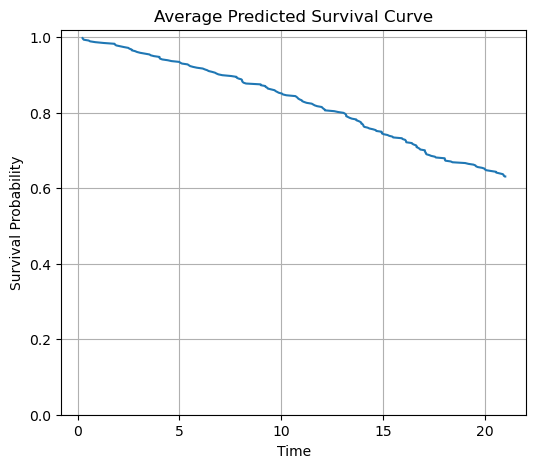

In [205]:
# Covariates only
X = matched_mnd_miros.drop(columns=["Disease_Duration", "Event"])

# Predict survival for every patient
surv = cph_synthetic.predict_survival_function(X)

# Average across patients
mean_survival = surv.mean(axis=1)

plt.figure(figsize=(6,5))
plt.plot(mean_survival.index, mean_survival.values)

plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Average Predicted Survival Curve")
plt.ylim(0, 1.02)
plt.grid(True)
plt.show()


#### ***Implementing SurvivalGAN***

In [206]:
matched_mnd_miros.head(3)
survivalgan_df = matched_mnd_miros
print(survivalgan_df.shape)
survivalgan_df.head(3)

(464, 9)


,Disease_Duration,Event,Vital_capacity,Age,Diagnostic_Delay,ALSFRS,El_Escorial,Onset_Limb,Sex_Male
0,11.124000,1,97.0,74.230003,12.713535,38.52,0,0,1
1,13.932013,1,119.0,61.200001,7.030223,36.69,0,0,0
2,12.791989,1,83.0,42.430000,5.913272,25.34,0,1,0


In [207]:
# Load data for Synthcity
plugins = Plugins()
# print(plugins.list())

loader = SurvivalAnalysisDataLoader(
    survivalgan_df,
    target_column='Event',
    time_to_event_column='Disease_Duration')

[2026-07-06T20:27:29.878645+0100][33379][CRITICAL] module disabled: /opt/anaconda3/envs/survivalgan_env/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py


In [208]:
# generic_loader = GenericDataLoader(survivalgan_df,arget_column="Event")
# model = Plugins().get("ctgan", n_iter=1, batch_size=64, random_state=42)
# model.fit(generic_loader)

In [217]:
# Train SurvivalGAN
gan_syn_model = plugins.get(
    "survival_gan",
    n_iter=1000,
    batch_size=16,
    random_state=42
)

gan_syn_model.fit(loader)

[2026-07-06T20:34:24.977754+0100][33379][CRITICAL] module disabled: /opt/anaconda3/envs/survivalgan_env/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
 60%|█████▉    | 599/1000 [03:11<02:08,  3.13it/s]


In [218]:
# Train SurvivalGAN
ctgan_syn_model = plugins.get(
    "survival_ctgan",
    n_iter=1000,
    batch_size=16,
    random_state=402
)

ctgan_syn_model.fit(loader)

[2026-07-06T20:43:47.345643+0100][33379][CRITICAL] module disabled: /opt/anaconda3/envs/survivalgan_env/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
 65%|██████▍   | 649/1000 [03:21<01:48,  3.23it/s]


In [220]:
# Train SurvivalGAN
nflow_syn_model = plugins.get(
    "survival_nflow",
    n_iter=1000,
    batch_size=16,
    random_state=402
)

nflow_syn_model.fit(loader)

[2026-07-06T20:48:05.515209+0100][33379][CRITICAL] module disabled: /opt/anaconda3/envs/survivalgan_env/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
 55%|█████▍    | 549/1000 [00:36<00:30, 14.85it/s]


In [221]:
# Generate synthetic placebo patients
n_synthetic = 500

gan_synthetic_loader = gan_syn_model.generate(count=n_synthetic)
gan_synthetic_placebo = gan_synthetic_loader.dataframe()

ctgan_synthetic_loader = ctgan_syn_model.generate(count=n_synthetic)
ctgan_synthetic_placebo = ctgan_synthetic_loader.dataframe()

nflow_synthetic_loader = nflow_syn_model.generate(count=n_synthetic)
nflow_synthetic_placebo = nflow_synthetic_loader.dataframe()

gan_synthetic_placebo.head()
gan_synthetic_placebo.shape

(500, 9)

In [222]:
# Apply administrative censoring at 21 months
tau = 21
time_col = 'Disease_Duration'
event_col = 'Event'

gan_synthetic_placebo["time_21"] = np.minimum(gan_synthetic_placebo[time_col], tau)
gan_synthetic_placebo["event_21"] = np.where(
    (gan_synthetic_placebo[time_col] <= tau) & (gan_synthetic_placebo[event_col] == 1),
    1, 0)

ctgan_synthetic_placebo["time_21"] = np.minimum(ctgan_synthetic_placebo[time_col], tau)
ctgan_synthetic_placebo["event_21"] = np.where(
    (ctgan_synthetic_placebo[time_col] <= tau) & (ctgan_synthetic_placebo[event_col] == 1),
    1, 0)  

nflow_synthetic_placebo["time_21"] = np.minimum(nflow_synthetic_placebo[time_col], tau)
nflow_synthetic_placebo["event_21"] = np.where(
    (nflow_synthetic_placebo[time_col] <= tau) & (nflow_synthetic_placebo[event_col] == 1),
    1, 0)  

In [223]:
real_placebo = survivalgan_df.copy()

# real_placebo["time_21"] = np.minimum(real_placebo[time_col], tau)

# real_placebo["event_21"] = np.where(
#     (real_placebo[time_col] <= tau) & (real_placebo[event_col] == 1),
#     1,
#     0
# )

real_placebo["time_21"] = real_placebo[time_col]

real_placebo["event_21"] = real_placebo[event_col]

In [224]:
real_placebo.head(2)

,Disease_Duration,Event,Vital_capacity,Age,Diagnostic_Delay,ALSFRS,El_Escorial,Onset_Limb,Sex_Male,time_21,event_21
0,11.124000,1,97.0,74.230003,12.713535,38.52,0,0,1,11.124000,1
1,13.932013,1,119.0,61.200001,7.030223,36.69,0,0,0,13.932013,1


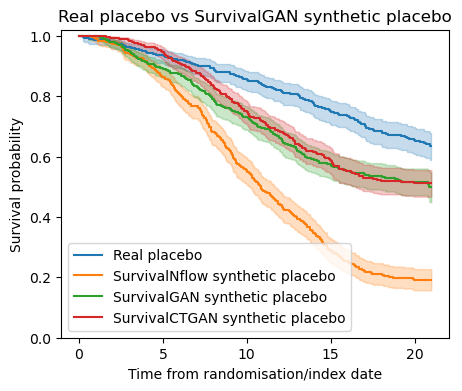

In [225]:
time_col = 'Disease_Duration'
event_col = 'Event'

kmf = KaplanMeierFitter()

plt.figure(figsize=(5, 4))

kmf.fit(real_placebo[time_col], real_placebo[event_col], label="Real placebo")
kmf.plot_survival_function(ci_show=True)

kmf.fit(nflow_synthetic_placebo[time_col],nflow_synthetic_placebo[event_col],label="SurvivalNflow synthetic placebo")
kmf.plot_survival_function(ci_show=True)

kmf.fit(gan_synthetic_placebo[time_col],gan_synthetic_placebo[event_col],label="SurvivalGAN synthetic placebo")
kmf.plot_survival_function(ci_show=True)

kmf.fit(ctgan_synthetic_placebo[time_col],ctgan_synthetic_placebo[event_col],label="SurvivalCTGAN synthetic placebo")
kmf.plot_survival_function(ci_show=True)

plt.xlabel("Time from randomisation/index date")
plt.ylabel("Survival probability")
plt.title("Real placebo vs SurvivalGAN synthetic placebo")
plt.ylim(0, 1.02)
plt.show()

In [226]:
# Compute RMST
def compute_rmst_from_km(df, time_col=time_col, event_col=event_col, tau=tau):
    kmf = KaplanMeierFitter()
    kmf.fit(df[time_col], df[event_col])

    surv = kmf.survival_function_.reset_index()
    surv.columns = ["time", "survival"]

    surv = pd.concat([
        pd.DataFrame({"time": [0], "survival": [1.0]}),
        surv
    ], ignore_index=True)

    surv = surv[surv["time"] <= tau].copy()

    if surv["time"].max() < tau:
        surv = pd.concat([
            surv,
            pd.DataFrame({
                "time": [tau],
                "survival": [surv["survival"].iloc[-1]]
            })
        ], ignore_index=True)

    times = surv["time"].values
    survival = surv["survival"].values

    return np.sum(np.diff(times) * survival[:-1])

rmst_real = compute_rmst_from_km(real_placebo, tau=tau)
gan_rmst_syn = compute_rmst_from_km(gan_synthetic_placebo, tau=tau)
ctgan_rmst_syn = compute_rmst_from_km(ctgan_synthetic_placebo, tau=tau)
nflow_rmst_syn = compute_rmst_from_km(nflow_synthetic_placebo, tau=tau)

print("Real placebo RMST:", rmst_real)
print("SurvivalGAN synthetic placebo RMST:", gan_rmst_syn)
print("Difference:", gan_rmst_syn - rmst_real)
print()
print("SurvivalCTGAN synthetic placebo RMST:", ctgan_rmst_syn)
print("Difference:", ctgan_rmst_syn - rmst_real)
print()
print("SurvivalNflow synthetic placebo RMST:", nflow_rmst_syn)
print("Difference:", nflow_rmst_syn - rmst_real)



Real placebo RMST: 17.502620977730587
SurvivalGAN synthetic placebo RMST: 15.266851658206043
Difference: -2.235769319524543

SurvivalCTGAN synthetic placebo RMST: 15.682080335273
Difference: -1.820540642457587

SurvivalNflow synthetic placebo RMST: 11.750089753728705
Difference: -5.752531224001881


In [139]:
real_placebo.head(2)

,Disease_Duration,Event,Vital_capacity,Age,ALSFRS,El_Escorial,Onset_Limb,Sex_Male,Diagnostic_Delay_l,time_21,event_21
0,11.124000,1,97.0,74.230003,38.52,0,0,1,2.618383,11.124000,1
1,13.932013,1,119.0,61.200001,36.69,0,0,0,2.083212,13.932013,1


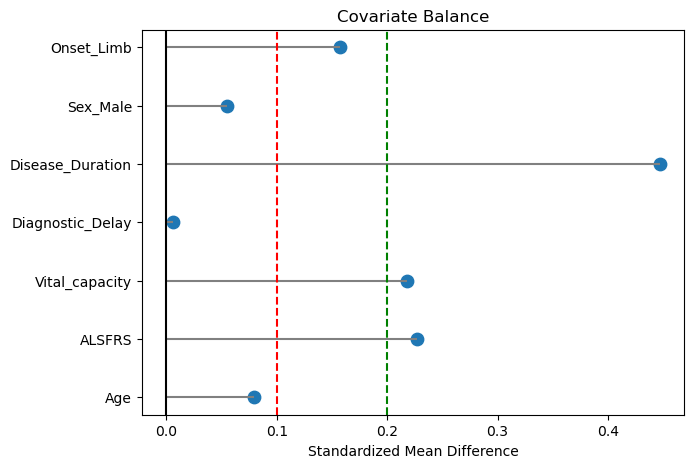

In [236]:
continuous_cols = ["Age", "ALSFRS", "Vital_capacity", "Diagnostic_Delay", 'Disease_Duration']
binary_cols = ["Sex_Male", "Onset_Limb"]

def smd_continuous(real, syn):
    pooled_sd = np.sqrt((real.var(ddof=1) + syn.var(ddof=1))/2)
    return np.abs((syn.mean() - real.mean())/pooled_sd)

def smd_binary(real, syn):
    p1 = real.mean()
    p2 = syn.mean()
    pooled = np.sqrt((p1*(1-p1)+p2*(1-p2))/2)
    return np.abs((p2-p1)/pooled)

def standardized_mean_differences(real, syn):
    smds = {}

    for col in continuous_cols:
        smds[col] = smd_continuous(
            real[col].dropna(),
            syn[col].dropna()
        )

    for col in binary_cols:
        smds[col] = smd_binary(
            real[col].dropna(),
            syn[col].dropna()
        )

    smd_df = pd.DataFrame({
        "Variable": smds.keys(),
        "SMD": smds.values()
    })

    plt.figure(figsize=(7,5))

    plt.hlines(
        y=smd_df["Variable"],
        xmin=0,
        xmax=smd_df["SMD"],
        color="grey"
    )

    plt.scatter(
        smd_df["SMD"],
        smd_df["Variable"],
        s=80
    )

    plt.axvline(0, color="black")
    plt.axvline(0.1, linestyle="--", color="red")
    plt.axvline(0.2, linestyle="--", color="green")

    plt.xlabel("Standardized Mean Difference")
    plt.title("Covariate Balance")
    plt.show()

standardized_mean_differences(real_placebo, gan_synthetic_placebo)

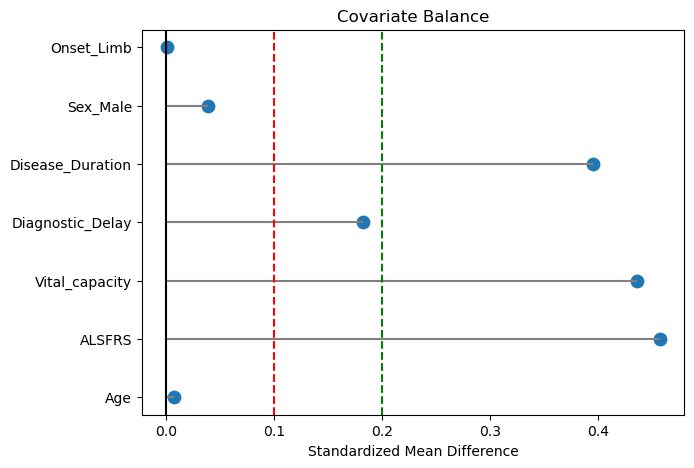

In [237]:
standardized_mean_differences(real_placebo, ctgan_synthetic_placebo)

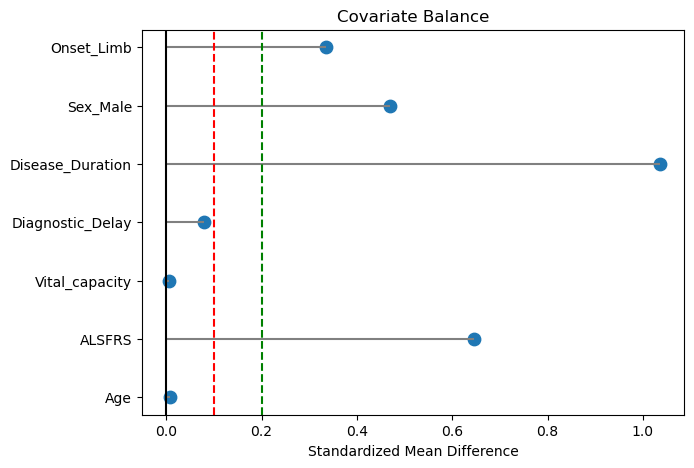

In [238]:
standardized_mean_differences(real_placebo, nflow_synthetic_placebo)

In [197]:
# Repeat generation several times

def Repeat_generation_several_times_for_RMST_comparison(syn_model):
    rmst_values = []

    for seed in range(100):
        synthetic_loader = syn_model.generate(count=n_synthetic)
        syn = synthetic_loader.dataframe()

        syn["time_21"] = np.minimum(syn[time_col], tau)

        syn["event_21"] = np.where(
            (syn[time_col] <= tau) & (syn[event_col] == 1), 1, 0)

        rmst_values.append(
            compute_rmst_from_km(syn, tau=tau))

    rmst_values = np.array(rmst_values)

    print("Mean synthetic RMST:", rmst_values.mean())
    print("95% interval:", np.percentile(rmst_values, [2.5, 97.5]))
    print("Observed placebo RMST:", rmst_real)

Repeat_generation_several_times_for_RMST_comparison(gan_syn_model)

Mean synthetic RMST: 15.648151943884393
95% interval: [15.25049185 16.04096602]
Observed placebo RMST: 17.502620977730587


In [198]:
Repeat_generation_several_times_for_RMST_comparison(ctgan_syn_model)

Mean synthetic RMST: 15.509870121883951
95% interval: [14.86158631 16.10373259]
Observed placebo RMST: 17.502620977730587


In [199]:
Repeat_generation_several_times_for_RMST_comparison(nflow_syn_model)

Mean synthetic RMST: 13.123521491194413
95% interval: [12.69524316 13.59659598]
Observed placebo RMST: 17.502620977730587


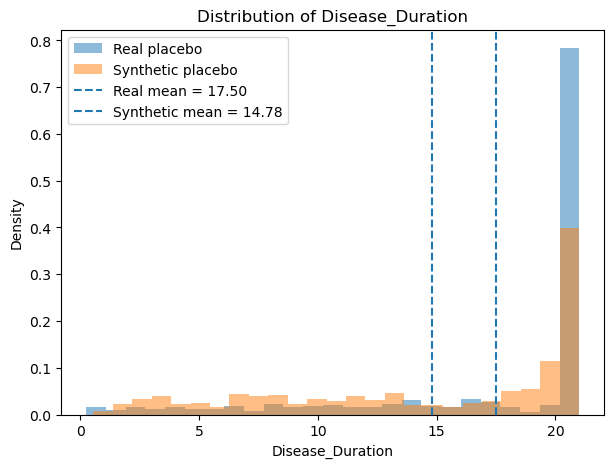

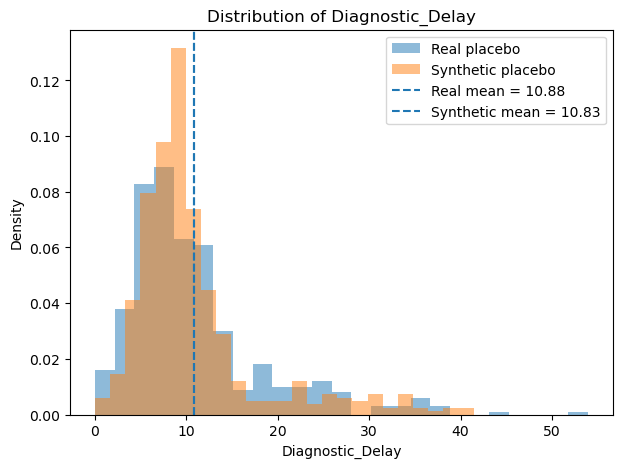

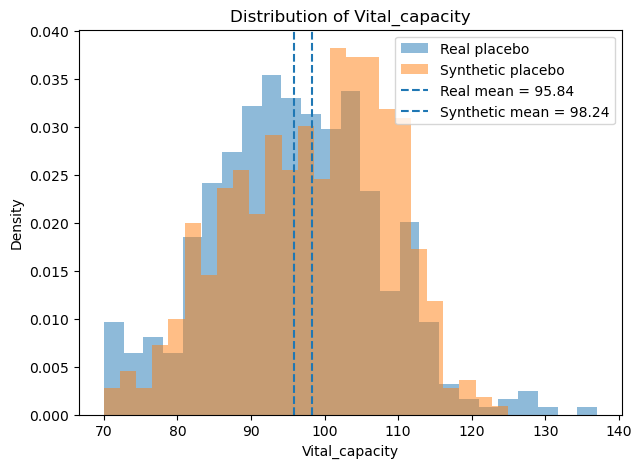

In [234]:
vars_to_plot = ["Disease_Duration","Diagnostic_Delay","Vital_capacity"]

def plot_distribution_comparison(real_df, synthetic_df, vars_to_plot, bins=25):
    for col in vars_to_plot:
        real = real_df[col].dropna()
        synthetic = synthetic_df[col].dropna()

        plt.figure(figsize=(7, 5))

        plt.hist(
            real,
            bins=bins,
            density=True,
            alpha=0.5,
            label="Real placebo"
        )

        plt.hist(
            synthetic,
            bins=bins,
            density=True,
            alpha=0.5,
            label="Synthetic placebo"
        )

        plt.axvline(real.mean(), linestyle="--", label=f"Real mean = {real.mean():.2f}")
        plt.axvline(synthetic.mean(), linestyle="--", label=f"Synthetic mean = {synthetic.mean():.2f}")

        plt.xlabel(col)
        plt.ylabel("Density")
        plt.title(f"Distribution of {col}")
        plt.legend()
        plt.show()

plot_distribution_comparison(
    real_placebo,
    gan_synthetic_placebo,
    vars_to_plot
)
